# Week 11: Clustering Part 2
Include concepts such as density-based spatial clustering of applications with noise (DBSCAN), hierarchical agglomerative clustering (HAC), linkage methods in HAC, and dendrograms.

In [ ]:
# Data Science Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold,
    RepeatedStratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

# Language Processing
import nltk
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# globals
random_state = 42

In [6]:
def test_num_of_clusters(X, max_k=10, method='elbow'):
    # Test K values and store results
    if method == 'elbow':
        k_values = range(1, max_k + 1)
        inertia = []
        for k in k_values:
            model = make_pipeline(
                StandardScaler(),
                KMeans(n_clusters=k, random_state=42)
            )
            model.fit(X)
            inertia.append(model.named_steps['kmeans'].inertia_)

        # Elbow Method
        plt.plot(k_values, inertia, marker='o')
        plt.xlabel('k')
        plt.ylabel('Inertia')
        plt.title('Elbow Method: Inertia vs. Number of Clusters')
        plt.show()
    
    if method == 'silhouette':
        k_values = range(2, max_k + 1)
        scores = []
        for k in k_values:
            model = make_pipeline(
                StandardScaler(),
                KMeans(n_clusters=k, random_state=42)
            )
            model.fit(X)
            score = silhouette_score(X, model.named_steps['kmeans'].labels_)
            scores.append(score)

        # Silhouette Score
        plt.plot(k_values, scores, marker='o')
        plt.xlabel('k')
        plt.ylabel('Silhouette Scores')
        plt.title('Silhouette Scores vs. Number of Clusters')
        plt.show()

In [7]:
def visualize_clusters(X, labels, y):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm', s=35)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title('Clusters Colored by Target Label')
    plt.show()

## Dataset 1: Web Page Phishing Detection

In [8]:
# Load cleaned data
cleaned_webpage = pd.read_csv('cleaned_webpage.csv')
cleaned_webpage.head()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,legitimate
0,37,19,0,3,0,0,0,0,0,0,...,0,1,0,45,0,0,1,1,4,1
1,77,23,1,1,0,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,0
2,126,50,1,4,1,0,1,2,0,3,...,1,0,0,14,4004,5828815,0,1,0,0
3,18,11,0,2,0,0,0,0,0,0,...,1,0,0,62,0,107721,0,0,3,1
4,55,15,0,2,2,0,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,1


In [16]:
# Define X (features) and y (target value)
X = cleaned_webpage.drop(columns=['legitimate'])
X_scaled = StandardScaler().fit_transform(X)

y = cleaned_webpage['legitimate']

In [18]:
def plot_k_distance(X, k=10):
    # Fit nearest neighbors
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    
    # Compute distances
    distances, indices = nn.kneighbors(X)
    
    # k-th column = distance to the k-th nearest neighbor
    k_distances = np.sort(distances[:, k-1])
    
    plt.figure(figsize=(8,5))
    plt.plot(k_distances)
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"{k}-distance")
    plt.title(f"{k}-Distance Plot for DBSCAN")
    plt.show()

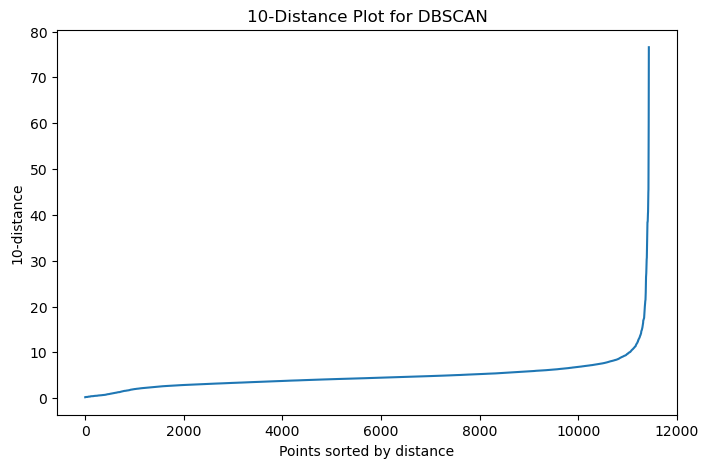

In [19]:
plot_k_distance(X_scaled, k=10)

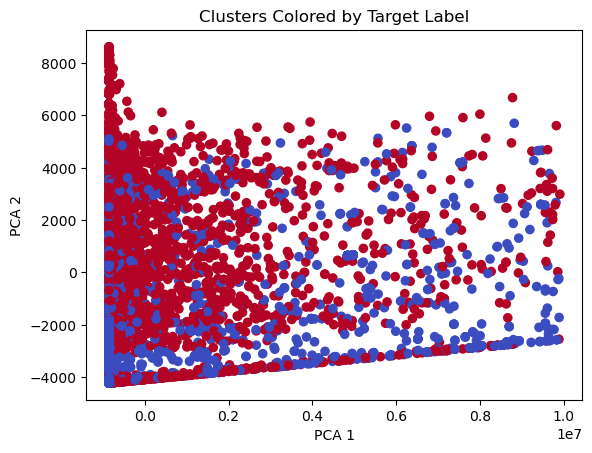

Clusters: 22
Noise points: 1440


In [27]:
db = DBSCAN(eps=6, min_samples=10).fit(X_scaled)
visualize_clusters(X, db.labels_, y)

# Cluster info
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = sum(db.labels_ == -1)
print("Clusters:", n_clusters)
print("Noise points:", n_noise)

In [ ]:
HAC = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = HAC.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50, alpha=0.5)
plt.title('HAC Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

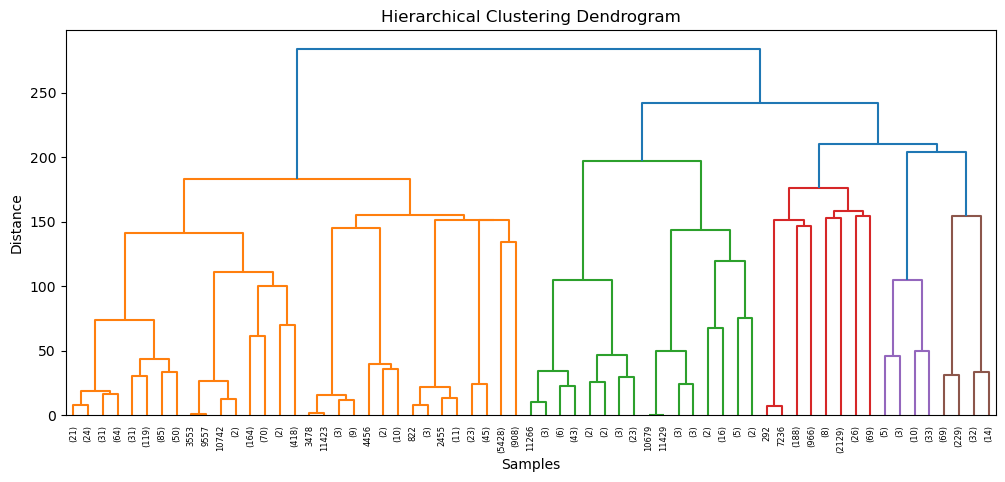

In [57]:
# Compute hierarchical clustering
links = linkage(X_scaled, method='ward')  # 'ward', 'complete', 'average'

# Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(links, truncate_mode='level', p=5)  # show only top 5 levels
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


## Dataset 2: Phishing Email Detection

In [29]:
# Load cleaned data
cleaned_email = pd.read_csv('cleaned_email.csv')
cleaned_email.head()

,Email Text,polarity,subjectivity,unique_words,char_count,word_count,uppercase_ratio,symbol_ratio,kw_urgent,kw_verify,kw_account,kw_click,kw_suspend,kw_update,kw_login,kw_confirm,currency_symbol_count,phone_number_count,Safe Email
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0.201493,0.514213,110.0,1030.0,230.0,0.000000,0.059223,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,the other side of * galicismos * * galicismo *...,0.009375,0.084375,53.0,479.0,91.0,0.000000,0.037578,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,re : equistar deal tickets are you still avail...,0.091540,0.515783,102.0,1245.0,305.0,0.000000,0.077108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,\nHello I am your hot lil horny toy.\n I am...,0.260069,0.690278,73.0,688.0,96.0,0.056686,0.162791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0
4,software at incredibly low prices ( 86 % lower...,0.152579,0.505258,60.0,441.0,91.0,0.000000,0.061224,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [30]:
# Define X (features) and y (target value)
X2 = cleaned_email.drop(columns=['Safe Email', 'Email Text'])
X2_scaled = StandardScaler().fit_transform(X2)

y2 = cleaned_email['Safe Email']

In [31]:
# Semantic Clustering
emails = cleaned_email['Email Text'].tolist()
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(emails)

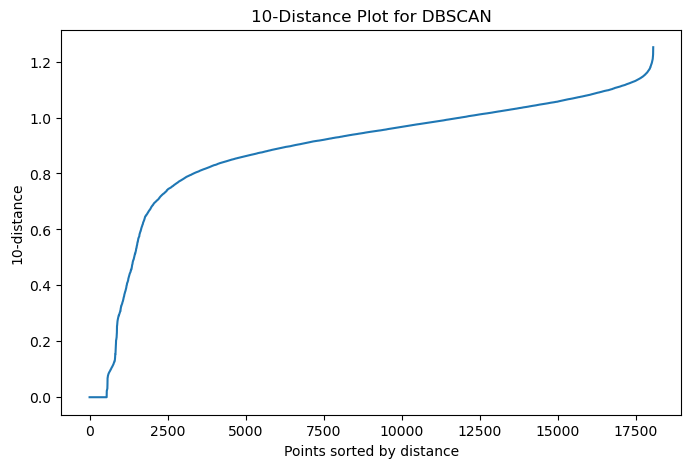

In [32]:
plot_k_distance(embeddings, k=10)

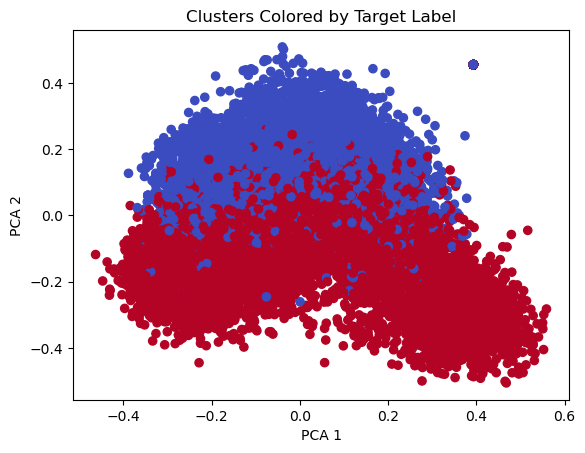

Clusters: 2
Noise points: 248


In [33]:
db2 = DBSCAN(eps=1.1, min_samples=10).fit(embeddings)
visualize_clusters(embeddings, db2.labels_, y2)

# Cluster info
n_clusters = len(set(db2.labels_)) - (1 if -1 in db2.labels_ else 0)
n_noise = sum(db2.labels_ == -1)
print("Clusters:", n_clusters)
print("Noise points:", n_noise)

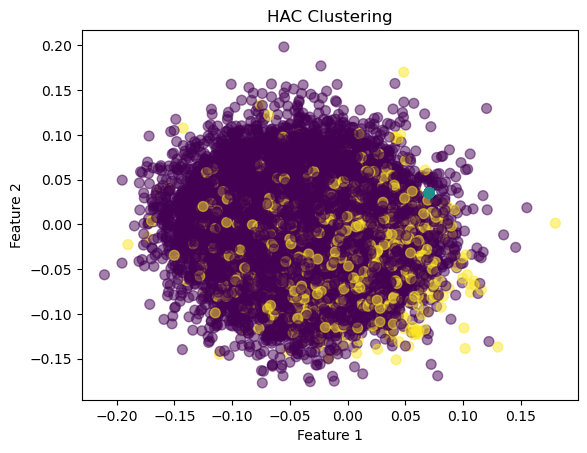

In [58]:
HAC = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = HAC.fit_predict(embeddings)

plt.scatter(embeddings[:, 0], embeddings[:, 1], c=labels, cmap='viridis', s=50, alpha=0.5)
plt.title('HAC Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

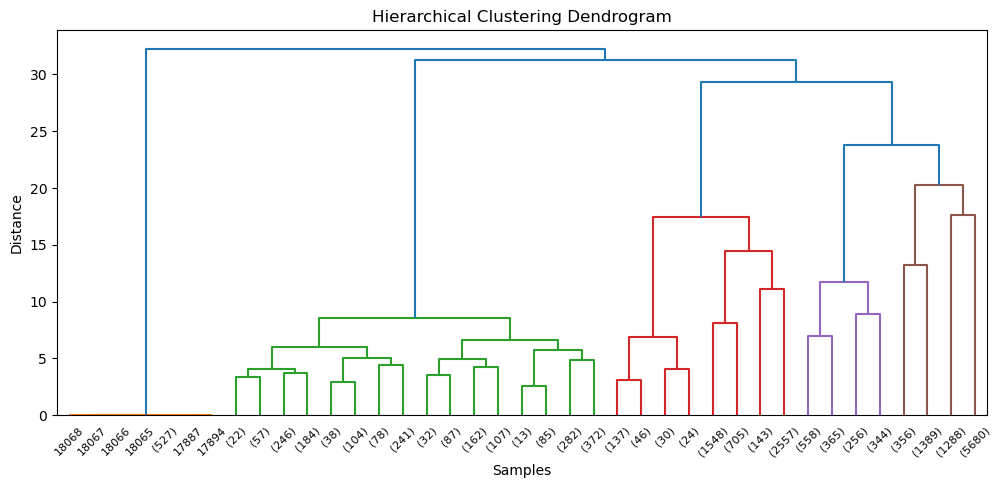

In [ ]:
# Compute hierarchical clustering
links2 = linkage(embeddings, method='ward')  # 'ward', 'complete', 'average'

# Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(links2, truncate_mode='level', p=5)  # show only top 5 levels
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Dataset 3: Credit Card Transactions Fraud Detection Dataset

In [35]:
# Load cleaned data
cleaned_credit_card = pd.read_csv('cleaned_ccd.csv')
cleaned_credit_card.head()

,cc_num,merchant,category,amt,gender,city,state,lat,long,city_pop,job,unix_time,merch_lat,merch_long,age,full_name,max_repeats,is_fraud
0,0,0,0,2.86,0,0,0,33.9659,-80.9355,333497,0,1371816865,33.986391,-81.200714,57,0,3,0
1,1,1,0,29.84,1,1,1,40.3207,-110.4360,302,1,1371816873,39.450498,-109.960431,35,1,4,0
2,2,2,1,41.28,1,2,2,40.6729,-73.5365,34496,2,1371816893,40.495810,-74.196111,55,2,4,0
3,3,3,2,60.05,0,3,3,28.5697,-80.8191,54767,3,1371816915,28.812398,-80.883061,38,3,4,0
4,4,4,3,3.19,0,4,4,44.2529,-85.0170,1126,4,1371816917,44.959148,-85.884734,70,4,3,0


In [36]:
# Group by merchant
groupbymerchant = cleaned_credit_card.groupby('merchant')
groupbymerchant.size()

merchant
0      2552
1      2610
2      2471
3      2340
4      1201
       ... 
688    1199
689    2338
690    1758
691    1864
692    1285
Length: 693, dtype: int64

In [42]:
merchant0 = cleaned_credit_card.query('merchant == 0').drop(columns=['merchant', 'category'])

In [48]:
# Define X (features) and y (target value)
X3 = merchant0.drop(columns=['is_fraud'])
X3_scaled = StandardScaler().fit_transform(X3)

y3 = merchant0['is_fraud']

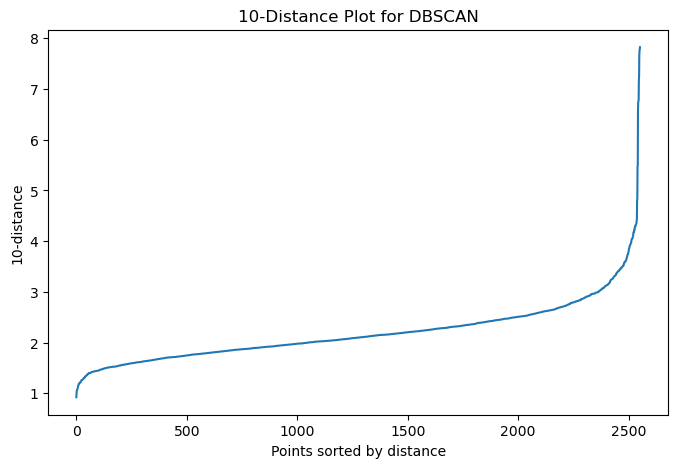

In [49]:
plot_k_distance(X3_scaled, k=10)

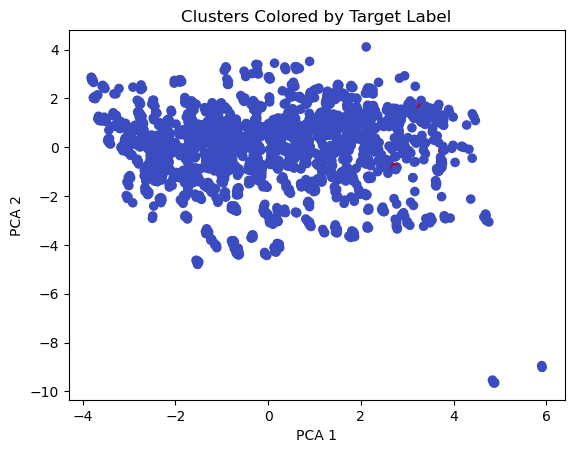

Clusters: 2
Noise points: 86


In [52]:
db3 = DBSCAN(eps=3, min_samples=10).fit(X3_scaled)
visualize_clusters(X3_scaled, db3.labels_, y3)

# Cluster info
n_clusters = len(set(db3.labels_)) - (1 if -1 in db3.labels_ else 0)
n_noise = sum(db3.labels_ == -1)
print("Clusters:", n_clusters)
print("Noise points:", n_noise)

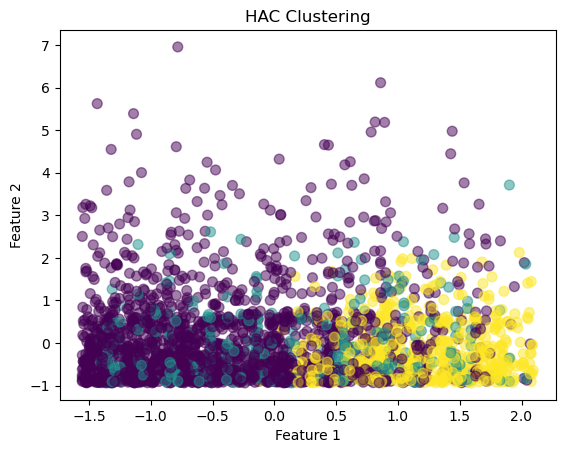

In [59]:
HAC = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = HAC.fit_predict(X3_scaled)

plt.scatter(X3_scaled[:, 0], X3_scaled[:, 1], c=labels, cmap='viridis', s=50, alpha=0.5)
plt.title('HAC Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

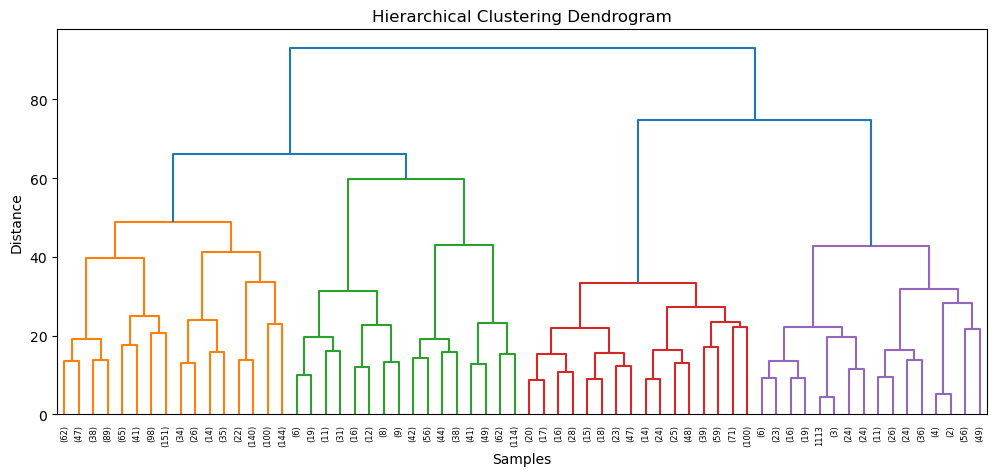

In [ ]:
# Compute hierarchical clustering
links3 = linkage(X3_scaled, method='ward')  # 'ward', 'complete', 'average'

# Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(links3, truncate_mode='level', p=5)  # show only top 5 levels
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()